In [91]:
#avg_voltage_initial_mV = initialVoltage = 0

VREF_STEP_IN_MICROVOLTS_NEGATIVE = 1000
VREF_STEP_IN_MICROVOLTS_POSITIVE = 4000


import matplotlib.pyplot as plt
import numpy as np

#max_volts = 4500


def v(volts, max_volts, hit_threshold_flag, direction_up_flag):
#    hit_threshold_flag = False
#    direction_up_flag = True
    
    if((not hit_threshold_flag) and max_volts != 0):
    
        threshold_low_mV = max_volts/20
        threshold_mV = max_volts - threshold_low_mV

        if (volts > threshold_mV):
            v = (((volts - threshold_mV)* 100) / threshold_low_mV)
            step_size = (((5000 - VREF_STEP_IN_MICROVOLTS) * v) / 100) + VREF_STEP_IN_MICROVOLTS
            return(step_size)
        else:
            hit_threshold_flag = True

    if(direction_up_flag):
        return(VREF_STEP_IN_MICROVOLTS_POSITIVE)
    return(VREF_STEP_IN_MICROVOLTS_NEGATIVE)

def add(a, b):
    return(a+b)

#volts_input = np.arange(0., 6000., 50.)

#plt.plot(volts_input, v(volts_input,), "ro")

#plt.show()

#import matplotlib.pyplot as plt
#import numpy as np

#from matplotlib import cm

#plt.style.use('_mpl-gallery')

import math

# Make data
size = 5000 #5000
incr = 250 #250
step = math.ceil(size/incr)

volts_initial = np.arange(0., 1000, 50)
volts_max = np.arange(0., size, incr)
#X, Y = np.meshgrid(X, Y)
#R = np.sqrt(X**2 + Y**2)
Z1 = [[0]*step]*step
Z2 = [[0]*step]*step
Z3 = [[0]*step]*step
Z4 = [[0]*step]*step


for (a, volt) in enumerate(volts_initial):
    for (b, mvolt) in enumerate(volts_max):
        Z1[a][b] = v(volt, mvolt, False, False)

for (a, volt) in enumerate(volts_initial):
    for (b, mvolt) in enumerate(volts_max):
        Z2[a][b] = v(volt, mvolt, False, True)
    
for (a, volt) in enumerate(volts_initial):
    for (b, mvolt) in enumerate(volts_max):
        Z3[a][b] = v(volt, mvolt, True, False)
    
for (a, volt) in enumerate(volts_initial):
    for (b, mvolt) in enumerate(volts_max):
        Z4[a][b] = v(volt, mvolt, True, True)
        









#Z = v(volts_initial, volts_max)

# Plot the surface
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
#ax.plot_surface(volts_initial, volts_max, Z)

#ax.set(xticklabels=[],
#       yticklabels=[],
#       zticklabels=[])

#plt.show()

#print(volts_initial)
#print(volts_max)
#print(Z)










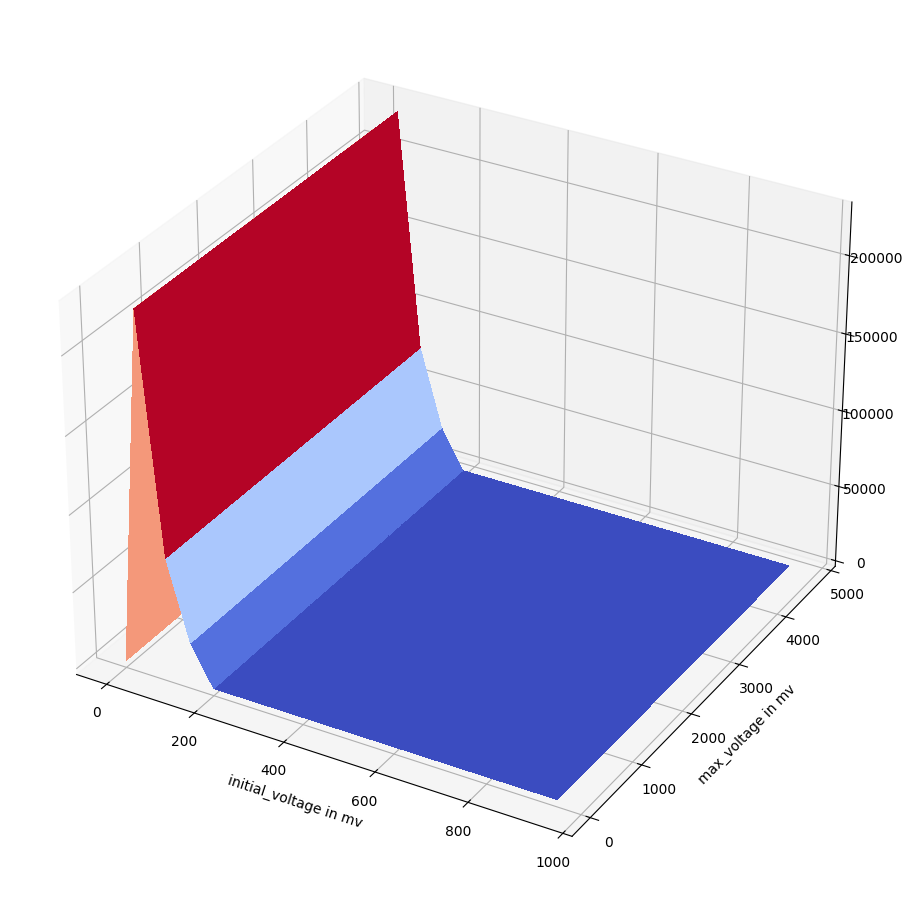

In [96]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')

plt.xlabel("initial_voltage in mv")
plt.ylabel("max_voltage in mv")

#X = volts_initial
#Y = volts_max
X, Y = np.meshgrid(volts_initial, volts_max)

Z = np.array(Z1)
ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=1, antialiased=False)
plt.show()
Z = np.array(Z2)
ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=1, antialiased=False)
plt.show()
Z = np.array(Z3)
ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=1, antialiased=False)
#plt.show()
Z = np.array(Z4)
ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=1, antialiased=False)
#plt.show()

